# wasi-graphviz quickstart

Local sandbox for poking at the public API. Run with the project's `uv` env:

```bash
uv sync --all-extras
uv run jupyter lab    # or: uv run jupyter notebook
```

Pick the kernel named after the project's `.venv` (`Python (.venv)` or similar).

In [1]:
from IPython.display import SVG, display
from wasi_graphviz import render

## Render a simple graph

`render()` returns `bytes`. For SVG we can hand it directly to IPython's `SVG` display.

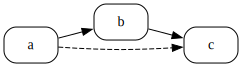

In [2]:
dot = '''
digraph G {
    rankdir=LR;
    node [shape=box, style=rounded];
    a -> b -> c;
    a -> c [style=dashed];
}
'''

display(SVG(render(dot)))

## Compare layout engines

engine=dot


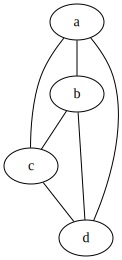

engine=neato


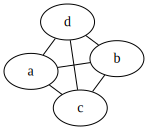

engine=circo


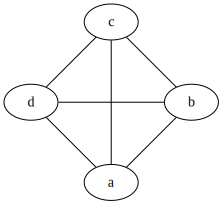

engine=fdp


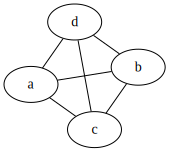

engine=twopi


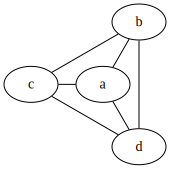

In [3]:
graph = 'graph G { a -- b -- c -- d -- a -- c; b -- d; }'

for engine in ['dot', 'neato', 'circo', 'fdp', 'twopi']:
    print(f'engine={engine}')
    display(SVG(render(graph, engine=engine)))

## Backend comparison

`auto` prefers `wasmtime` then falls back to `pywasm`. Force one explicitly to compare timings or sanity-check determinism.

In [4]:
import time

edges = ' '.join(f'n{i} -> n{i + 1};' for i in range(200))
big_dot = f'digraph G {{ {edges} }}'

for backend in ['wasmtime', 'pywasm']:
    t0 = time.perf_counter()
    out = render(big_dot, backend=backend)
    dt = time.perf_counter() - t0
    print(f'{backend:>8s}: {len(out):>7d} bytes in {dt * 1000:7.1f} ms')

wasmtime:  115248 bytes in    15.1 ms
  pywasm:  115248 bytes in 63162.2 ms


## Other output formats

`render` is format-agnostic — it returns whatever bytes Graphviz emits.

In [5]:
for fmt in ['dot', 'xdot', 'plain', 'json']:
    out = render('digraph G { a -> b; }', format=fmt)
    print(f'--- {fmt} ---')
    print(out.decode('utf-8')[:400])
    print()

--- dot ---
digraph G {
	graph [bb="0,0,54,108"];
	node [label="\N"];
	a	[height=0.5,
		pos="27,90",
		width=0.75];
	b	[height=0.5,
		pos="27,18",
		width=0.75];
	a -> b	[pos="e,27,36.104 27,71.697 27,64.407 27,55.726 27,47.536"];
}


--- xdot ---
digraph G {
	graph [_draw_="c 9 -#fffffe00 C 7 -#ffffff P 4 0 0 0 108 54 108 54 0 ",
		bb="0,0,54,108",
		xdotversion=1.7
	];
	node [label="\N"];
	a	[_draw_="c 7 -#000000 e 27 90 27 18 ",
		_ldraw_="F 14 11 -Times-Roman c 7 -#000000 T 27 85.8 0 6.21 1 -a ",
		height=0.5,
		pos="27,90",
		width=0.75];
	b	[_draw_="c 7 -#000000 e 27 18 27 18 ",
		_ldraw_="F 14 11 -Times-Roman c 7 -#000000 T 27 13.8 0

--- plain ---
graph 1 0.75 1.5
node a 0.375 1.25 0.75 0.5 a solid ellipse black lightgrey
node b 0.375 0.25 0.75 0.5 b solid ellipse black lightgrey
edge a b 4 0.375 0.99579 0.375 0.89454 0.375 0.77398 0.375 0.66022 solid black
stop


--- json ---
{
  "name": "G",
  "directed": true,
  "strict": false,
  "_draw_": 
  [
    {
      "op": "c",
      

## Error handling

In [6]:
from wasi_graphviz import RenderError

try:
    render('not valid dot {')
except RenderError as exc:
    print(f'caught: {exc}')

caught: Failed to parse DOT source
